# 🔬 Project Overview: Non-Inertial Forces and Object-Oriented Design

The core of this project is to model and calculate forces in **non-inertial reference frames** using **Object-Oriented Programming (OOP)**. The structure is built around the general force equation, where each term is calculated modularly.

---

## 🏗️ Core OOP Development Tasks

| Task | Objective | Primary OOP Concept | Highlight |
| :--- | :--- | :--- | :--- |
| **Ex. 1.1** | Create a class to handle **3D vector operations** (cross product, sum, difference). | **Encapsulation / Utility Class** | Hides the complexity of vector mathematics, allowing the main physics logic to focus on forces. |
| **Ex. 1.2** | Complete a class/method for calculating each specific **term of the force equation** (e.g., $m\vec{a}_{o}$, $m(\vec{\omega} \times (\vec{\omega} \times \vec{r}))$, etc.). | **Modularity / Encapsulation** | Isolates each force component (e.g., Centrifugal, Coriolis, fictitious) for independent testing and clear assembly. |

---

## 🌍 Advanced Application & OOP Principles

The later tasks demonstrate the flexibility and power of the OOP structure by applying the base methods to increasingly complex physical scenarios.

| Task | Scenario | Applied OOP Concept | Purpose |
| :--- | :--- | :--- | :--- |
| **Ex. 1.3** | Forces on an observer in an **accelerating train** (simple linear non-inertial frame). | **Method Reusability** | Demonstrates the ability to reuse the general force calculation methods with simple linear acceleration inputs. |
| **Ex. 1.4** | Forces on a body on the **Earth's surface** (requires Coriolis and Centrifugal forces). | **Inheritance / Data Encapsulation** | Could be implemented by defining an **`EarthFrame`** class that inherits from a generic **`NonInertialFrame`** class, encapsulating constants like $R_{\text{Earth}}$ and $\vec{\omega}$ for consistent use. |
| **Ex. 1.5 (Bonus)** | Additional force terms when the body has a **velocity relative to the rotating observer** ($\vec{v}'$). | **Polymorphism / Method Overloading** | Requires extending or adapting existing calculation methods (specifically the Coriolis term, $2m(\vec{\omega} \times \vec{r}')$) to correctly handle the new relative velocity input $\vec{v}'$ without breaking existing uses. |

---

## ✅ Key Takeaway

By designing the project with OOP, we build a **modular and reusable** system. We can easily transition from a simple accelerating train to the complex rotation of the Earth simply by setting new object properties or calling methods with different input values.

# ex1.1/1.2



In [2]:
import numpy as np
R_earth = 6371 * 10**3  
M_earth = 5.97 * 10**24  
G = 6.67 * 10**-11  
g = 9.81 

class newtoneq:
    
    def __init__(self, m,r, omega, v_sigma, a0, omegadot):
        self.m = np.array(m)
        self.r = np.array(r)
        self.omega = np.array(omega)
        self.v_sigma = np.array(v_sigma)
        self.a0 = np.array(a0)
        self.omegadot = np.array(omegadot)
    
        
    def cross(self,vector1, vector2):
        return np.cross(vector1, vector2)
    
    def vector_add(vector1, vector2):
        return np.add(vector1, vector2)
    
    def vector_subtract(self, vector1, vector2):
        return np.subtract(vector1, vector2)

    
    def first_term(self):
        return self.m * np.array(self.a0) #F=ma_0
    
    def second_term(self):
        return self.m * cross(self.omegadot, self.r) #F=m(dw/dt)xr
    
    def third_term(self):
        return self.m * cross(self.omega, cross(self.omega, self.r))#F=mwx(wxr)
    
    def forth_term(self):
        return 2 * self.m * cross(self.omega, v_sigma)   #F=-2mwxv_body 

# Ex1.3
 

The inertial observer outside the train can only see the gravitational force on the pendulum and a string tension from its string, while the non-inertial observer inside the train  can see the gravitational force, the string tension and a pseudoforce in order to justify his observation of the pendulum being pushed the opposite way of the train's acceleration.

In [21]:
train = newtoneq(
    m=1,
    r=[0, 0, 0], # we assume the pendulum is at the origin (we won't need this vector anyway, since we aren't taking into account any forces that depend on the position of the pendulum)
    omega=[0, 0, 0],  # no rotation for the train
    v_sigma=[0, 0, 0],  # the pendulum is at rest inside the train
    a0=[3, 0, 0],  # acceleration of the train
    omegadot=[0, 0, 0],  # no angular acceleration for the train
)

# Non-inertial observer inside the train
def non_inertial_train_forces():
    F_gravity = train.m * g * np.array([0, 0, -1]) 
    F_string1 = train.vector_subtract(train.first_term(), F_gravity)  # tension in the string (since for the non-inertial observer the pendulum is at rest, under some angle)
    return F_gravity, F_string1, -train.first_term()

# Inertial observer outside the train
def inertial_train_forces():
    F_gravity = train.m * g * np.array([0, 0, -1])  
    F_string2 = train.m * train.vector_subtract(train.first_term(), F_gravity) # from Newton's second law
    return F_gravity, F_string2


non_inertial_forces = non_inertial_train_forces()
F_gravity, F_string, F_acceleration = non_inertial_forces


print("Non-inertial observer forces (inside the train):")
print("Gravitational force:", non_inertial_forces[0])
print("Tension of the string:", non_inertial_forces[1])
print("Train's acceleration force:", non_inertial_forces[2])


inertial_forces = inertial_train_forces()
print("\nInertial observer forces (outside the train):")
print("Gravitational force:", inertial_forces[0])
print("Tension of the string:", inertial_forces[1])

Non-inertial observer forces (inside the train):
Gravitational force: [ 0.    0.   -9.81]
Tension of the string: [3.   0.   9.81]
Train's acceleration force: [-3  0  0]

Inertial observer forces (outside the train):
Gravitational force: [ 0.    0.   -9.81]
Tension of the string: [3.   0.   9.81]


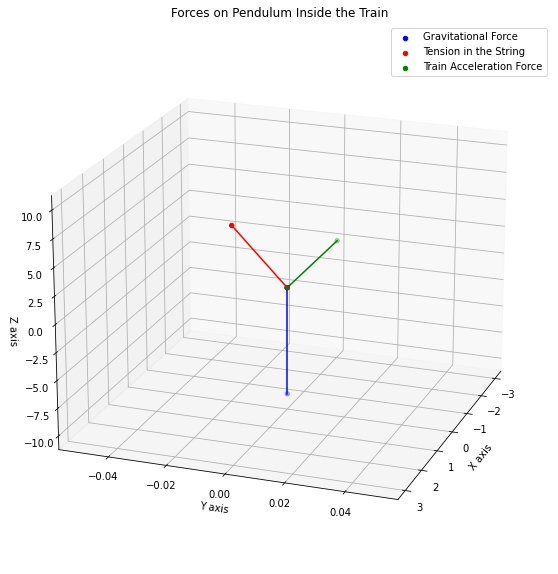

In [22]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')


ax.view_init(elev=20, azim=20)

# plot for forces acting on the pendulum inside the train
ax.scatter([0, F_gravity[0]], [0, F_gravity[1]], [0, F_gravity[2]], color='b', label='Gravitational Force')
ax.scatter([0, F_string[0]], [0, F_string[1]], [0, F_string[2]], color='r', label='Tension in the String')
ax.scatter([0, F_acceleration[0]], [0, F_acceleration[1]], [0, F_acceleration[2]], color='g', label='Train Acceleration Force')

# Plot lines connecting the origin to the forces
ax.plot([0, F_gravity[0]], [0, F_gravity[1]], [0, F_gravity[2]], color='b')
ax.plot([0, F_string[0]], [0, F_string[1]], [0, F_string[2]], color='r')
ax.plot([0, F_acceleration[0]], [0, F_acceleration[1]], [0, F_acceleration[2]], color='g')

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('Forces on Pendulum Inside the Train')

ax.legend()

plt.show()



# Ex. 1.4

In [23]:
omega_earth = np.array([0, 0, 463.89 / R_earth])  # Earth's angular velocity in rad/s
ball_mass = 1.0 
ball_position = np.array([0, 1,0]) * R_earth # ball is at the equator so its position is determined by radial vector that is facing away from the center of the Earth (in the y axis) 
observer_position = ball_position
v_sigma = np.array([0, 0, 0])  # ball is at rest relative to the observer

earth_observer = newtoneq(
    m=1,
    r=ball_position,
    omega=omega_earth,  
    v_sigma=v_sigma, 
    a0=[0, 0, 0],  
    omegadot=[0, 0, 0]
)

#Forces acting on the ball as seen by the observer on the surface of the Earth,

def forces_earth_observer():
    F_gravity = -earth_observer.m * g * (earth_observer.r / R_earth)
    F_centrifugal = -earth_observer.m * earth_observer.cross(omega_earth, earth_observer.cross(omega_earth, earth_observer.r))
    F_floor = - F_gravity
    return F_gravity , F_centrifugal, F_floor

#Forces acting on the ball as seen by an alien

def forces_alien_observer():
    F_gravity = -earth_observer.m * g * (earth_observer.r / R_earth)
    F_floor2 = - F_gravity
    return F_gravity, F_floor2

#Forces acting on the ball for a non-spinning Earth scenario

def forces_non_spinning_earth():
     F_gravity_without_spin = -earth_observer.m * g * np.array([0, 1,0 ]) 
     F_floor3 = - F_gravity_without_spin
     return F_gravity_without_spin, F_floor3
 
forces_earth = forces_earth_observer()
forces_alien = forces_alien_observer()
forces_no_spin = forces_non_spinning_earth()


print("Forces acting on the ball as seen by the observer on Earth's surface:")
print(f"Gravitational force: {forces_earth[0]} N")
print(f"floor resistance force: {forces_earth[2]} N\n")
print(f"Centrifugal force: {forces_earth[1]} N\n")

print("Forces acting on the ball as seen by the alien (in an inertial frame):")
print(f"Gravitational force: {forces_alien[0]} N")
print(f"floor resistance force: {forces_alien[1]} N\n")
print("(No centrifugal force for the alien)\n")

print("Forces acting on the ball for a non-spinning Earth scenario:")
print(f"Gravitational force: {forces_no_spin[0]} N")
print(f"floor resistance force: {forces_no_spin[1]} N\n")

Forces acting on the ball as seen by the observer on Earth's surface:
Gravitational force: [-0.   -9.81 -0.  ] N
floor resistance force: [0.   9.81 0.  ] N

Centrifugal force: [-0.         0.0337771 -0.       ] N

Forces acting on the ball as seen by the alien (in an inertial frame):
Gravitational force: [-0.   -9.81 -0.  ] N
floor resistance force: [0.   9.81 0.  ] N

(No centrifugal force for the alien)

Forces acting on the ball for a non-spinning Earth scenario:
Gravitational force: [-0.   -9.81 -0.  ] N
floor resistance force: [0.   9.81 0.  ] N



# Ex. 1.5

In [24]:
#In this scenario we need to calculate this parameter of the original equation: -2 * m * (omega × v_sigma) 
coriolis =newtoneq(
    m=1,
    r=ball_position,
    omega=omega_earth,  
    v_sigma=[3,0,0], 
    a0=[0, 0, 0],  
    omegadot=[0, 0, 0]
)
def coriolis_force():
    return -2 * coriolis.m * coriolis.cross(coriolis.omega, coriolis.v_sigma)
F_c = coriolis_force()
print("\nThe calculated Coriolis force is:")
print(f"F_c = {F_c} N")


The calculated Coriolis force is:
F_c = [-0.         -0.00043688 -0.        ] N
